# Predicting Rent From Property Features project

In [1]:
# importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# dataset from kaggle
df = pd.read_csv("House_Rent_Dataset.csv")

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [6]:
df.columns.tolist()

['Posted On',
 'BHK',
 'Rent',
 'Size',
 'Floor',
 'Area Type',
 'Area Locality',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Bathroom',
 'Point of Contact']

In [7]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df = df.drop_duplicates().copy()

In [11]:
# Convert the target and numerical inputs to numeric values
for col in ["Rent", "BHK", "Size", "Bathroom"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with invalid targets
df = df.dropna(subset=["Rent"])
df = df[df["Rent"] > 0]

print("Cleaned shape:", df.shape)
print(df[["Rent", "BHK", "Size", "Bathroom"]].describe())

Cleaned shape: (4746, 12)
               Rent          BHK         Size     Bathroom
count  4.746000e+03  4746.000000  4746.000000  4746.000000
mean   3.499345e+04     2.083860   967.490729     1.965866
std    7.810641e+04     0.832256   634.202328     0.884532
min    1.200000e+03     1.000000    10.000000     1.000000
25%    1.000000e+04     2.000000   550.000000     1.000000
50%    1.600000e+04     2.000000   850.000000     2.000000
75%    3.300000e+04     3.000000  1200.000000     2.000000
max    3.500000e+06     6.000000  8000.000000    10.000000


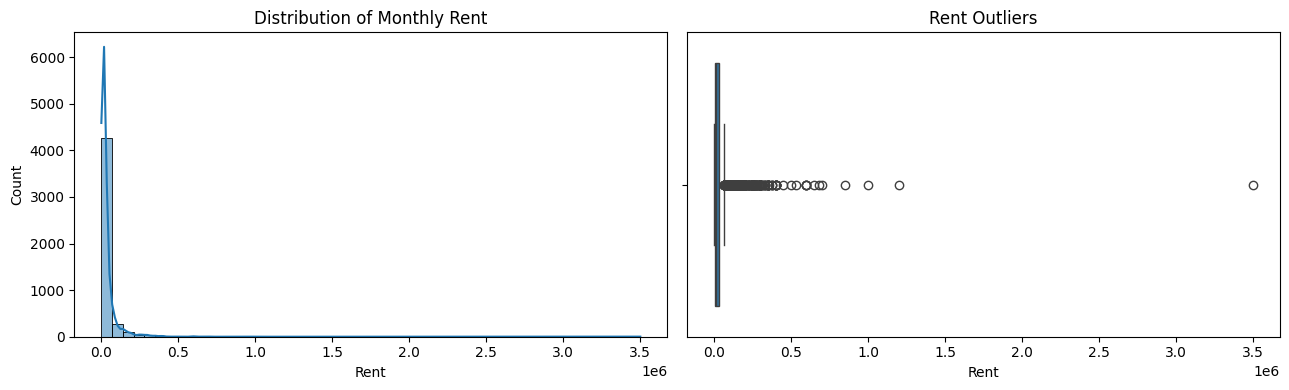

Mean Rent: 34993.45132743363
Median rent: 16000.0
90th percentile: 72000.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["Rent"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Monthly Rent")

sns.boxplot(x=df["Rent"], ax=axes[1])
axes[1].set_title("Rent Outliers")

plt.tight_layout()
plt.show()

print("Mean Rent:", df["Rent"].mean())
print("Median rent:", df["Rent"].median())
print("90th percentile:", df["Rent"].quantile(0.90))

In [14]:
# Extract floor number and total building floors
floor_text = df["Floor"].fillna("").astype(str)

floor_number = floor_text.str.extract(
    r"^\s*(\d+)"
)[0]

floor_number = floor_number.fillna(
    floor_text.str.extract(r"(?i)^(ground|lower ground|upper ground)")[0]
    .map({
        "ground": 0,
        "lower ground": 0,
        "upper ground": 1
    })
)

df["Floor_Number"] = pd.to_numeric(
    floor_number, errors="coerce"
)

df["Total_Floors"] = pd.to_numeric(
    floor_text.str.extract(r"(?i)\bout of\s+(\d+)")[0],
    errors="coerce"
)

In [15]:
# Use only columns that actually exist
candidate_features = [
    "BHK", "Size", "Bathroom",
    "Floor_Number", "Total_Floors",
    "City", "Furnishing Status", "Area Type",
    "Tenant Preferred", "Point of Contact",
    "Area Locality"
]

features = [c for c in candidate_features if c in df.columns]

print("Selected features:", features)

Selected features: ['BHK', 'Size', 'Bathroom', 'Floor_Number', 'Total_Floors', 'City', 'Furnishing Status', 'Area Type', 'Tenant Preferred', 'Point of Contact', 'Area Locality']


In [16]:
X = df[features].copy()
y = df["Rent"].copy()

In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [18]:
print("Training rows:", len(X_train_raw))
print("Testing rows:", len(X_test_raw))

Training rows: 3796
Testing rows: 950


In [19]:
# Handle missing values and encode categories

In [50]:
numeric_cols = X_train_raw.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = [
    c for c in X_train_raw.columns
    if c not in numeric_cols
]

In [21]:
# Fit numerical imputations using training data only
medians = X_train_raw[numeric_cols].median()

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

In [22]:
# Keep only the 20 most common localities in the training set
if "Area Locality" in categorical_cols:
    top_localities = X_train["Area Locality"].value_counts().head(20).index

    for part in [X_train, X_test]:
        part["Area Locality"] = part["Area Locality"].where(
            part["Area Locality"].isin(top_localities),
            "Other"
        )

In [23]:
# Learn category values from the training set
for col in categorical_cols:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

X_train = pd.get_dummies(X_train, columns=categorical_cols, dtype=float)
X_test = pd.get_dummies(X_test, columns=categorical_cols, dtype=float)


In [24]:
# Match test columns to training columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Use NumPy arrays for vectorized calculations
X_train = X_train.to_numpy(dtype=float)
X_test = X_test.to_numpy(dtype=float)

y_train = y_train.to_numpy(dtype=float)
y_test = y_test.to_numpy(dtype=float)

print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)

Training matrix: (3796, 44)
Testing matrix: (950, 44)


In [25]:
# Scale the features

In [26]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

In [27]:
# Avoid division by zero for constant features
X_std[X_std == 0] = 1

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("First five scaled rows:\n", X_train_scaled[:5, :5])
print("First five feature means:", X_train_scaled.mean(axis=0)[:5])

First five scaled rows:
 [[-0.10773946 -0.02691966  0.03566558  0.41486179  0.11976694]
 [-0.10773946 -0.2631174   0.03566558 -0.1469035  -0.31352856]
 [-1.30009808 -0.66465355 -1.09255559 -0.33415859 -0.42185244]
 [-1.30009808 -0.79062568 -1.09255559 -0.1469035  -0.31352856]
 [-0.10773946 -0.10565224  0.03566558  0.0403516  -0.20520469]]
First five feature means: [-9.59307566e-17  4.91352656e-17  9.12512075e-17  0.00000000e+00
  2.78433172e-17]


In [28]:
# Transform the target

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Example actual rents:", y_train[:5])
print("Example log-rents:", y_train_log[:5])

Example actual rents: [23500. 10500. 19000. 20000. 17000.]
Example log-rents: [10.06479825  9.25922577  9.85224689  9.90353755  9.74102744]


In [29]:
# Build Linear Regression from scratch

In [30]:
def predict(X, w, b):
    return X @ w + b


def compute_cost(X, y, w, b):
    m = len(y)

    errors = predict(X, w, b) - y

    cost = np.sum(errors ** 2) / (2 * m)

    return cost

In [31]:
# compute the gradients

def compute_gradients(X, y, w, b):
    m = len(y)

    errors = predict(X, w, b) - y

    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m

    return dj_dw, dj_db

In [32]:
def batch_gradient_descent(
    X, y, learning_rate=0.03, epochs=2000
):
    m, n = X.shape

    w = np.zeros(n)
    b = 0.0

    cost_history = []

    for epoch in range(epochs):
        dj_dw, dj_db = compute_gradients(X, y, w, b)

        w -= learning_rate * dj_dw
        b -= learning_rate * dj_db

        if epoch % 10 == 0:
            cost_history.append(
                compute_cost(X, y, w, b)
            )

    return w, b, cost_history

Final training cost: 0.0809011018384364


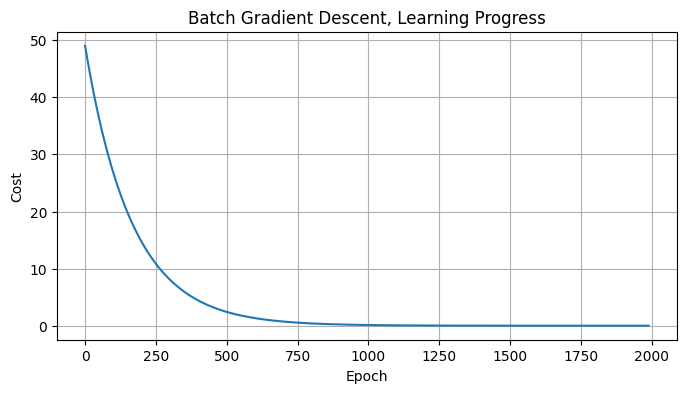

In [55]:
# Train the model

w_batch, b_batch, cost_history = batch_gradient_descent(
    X_train_scaled,
    y_train_log,
    learning_rate=0.003,
    epochs=2000
)

print("Final training cost:", cost_history[-1])

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(cost_history)) * 10, cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Batch Gradient Descent, Learning Progress")
plt.grid(True)
plt.show()

In [36]:
# Mini-batch Gradient Descent
def mini_batch_gradient_descent(
    X, y, learning_rate=0.03,
    epochs=300, batch_size=64, seed=42
):
    rng = np.random.default_rng(seed)

    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    cost_history = []

    for epoch in range(epochs):
        indices = rng.permutation(m)

        for start in range(0, m, batch_size):
            batch_indices = indices[start:start + batch_size]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            dj_dw, dj_db = compute_gradients(
                X_batch, y_batch, w, b
            )

            w -= learning_rate * dj_dw
            b -= learning_rate * dj_db

        cost_history.append(
            compute_cost(X, y, w, b)
        )

    return w, b, cost_history

# Compare batch and mini-batch training

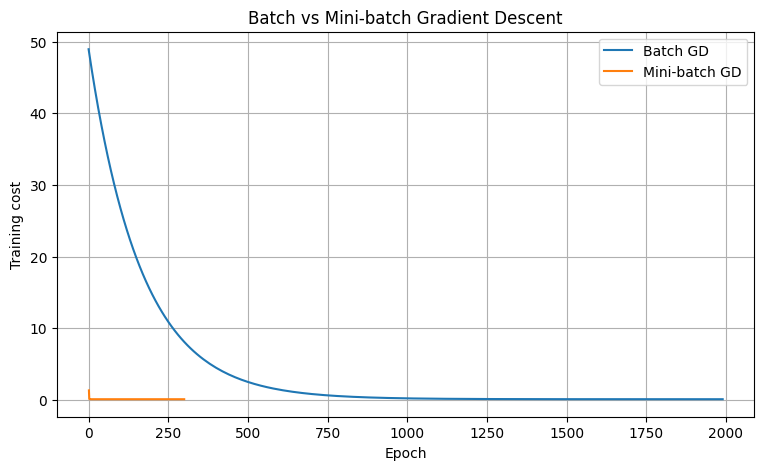

Batch final cost: 0.0809011018384364
Mini-batch final cost: 0.08057573890388163


In [38]:
w_mini, b_mini, mini_cost = mini_batch_gradient_descent(
    X_train_scaled,
    y_train_log,
    learning_rate=0.03,
    epochs=300,
    batch_size=64
)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(len(cost_history)) * 10,
    cost_history,
    label="Batch GD"
)

plt.plot(
    np.arange(1, len(mini_cost) + 1),
    mini_cost,
    label="Mini-batch GD"
)

plt.xlabel("Epoch")
plt.ylabel("Training cost")
plt.title("Batch vs Mini-batch Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

print("Batch final cost:", cost_history[-1])
print("Mini-batch final cost:", mini_cost[-1])

# Evaluate the model

In [39]:
predicted_log = predict(
    X_test_scaled, w_batch, b_batch
)

y_pred = np.maximum(
    np.expm1(predicted_log), 0
)

print("Actual rents:", y_test[:10])
print("Predicted rents:", np.round(y_pred[:10], 2))

Actual rents: [ 16000.  12000.  28000.   8000.  46000.  17000.  57000.   9500. 400000.
  15000.]
Predicted rents: [ 13542.57  15603.9   30845.54  28635.86  75693.1   18190.44  60034.35
  13186.01 444032.98  12310.39]


In [40]:
# Calculate 
def evaluate_model(y_true, y_prediction):
    mae = mean_absolute_error(y_true, y_prediction)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_prediction)
    )

    r2 = r2_score(y_true, y_prediction)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


results = evaluate_model(y_test, y_pred)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

MAE: 10991.2427
RMSE: 33501.8315
R2: 0.7184


In [41]:
# baseline

baseline_prediction = np.full(
    len(y_test), y_train.mean()
)

baseline_results = evaluate_model(
    y_test, baseline_prediction
)

comparison = pd.DataFrame(
    [baseline_results, results],
    index=["Mean baseline", "Custom Batch GD"]
)

display(comparison)

,MAE,RMSE,R2
Mean baseline,30760.812683,63134.815112,-0.000156
Custom Batch GD,10991.242727,33501.831517,0.718378


# Compare with scikit-learn

In [42]:
sk_model = LinearRegression()

sk_model.fit(X_train_scaled, y_train_log)

sk_log_prediction = sk_model.predict(X_test_scaled)

sk_prediction = np.maximum(
    np.expm1(sk_log_prediction), 0
)

comparison = pd.DataFrame(
    [
        evaluate_model(y_test, y_pred),
        evaluate_model(y_test, sk_prediction)
    ],
    index=["Custom Gradient Descent", "Scikit-learn"]
)

display(comparison)

,MAE,RMSE,R2
Custom Gradient Descent,10991.242727,33501.831517,0.718378
Scikit-learn,10984.117066,31336.510181,0.753605


In [43]:
# investigating the learning rate

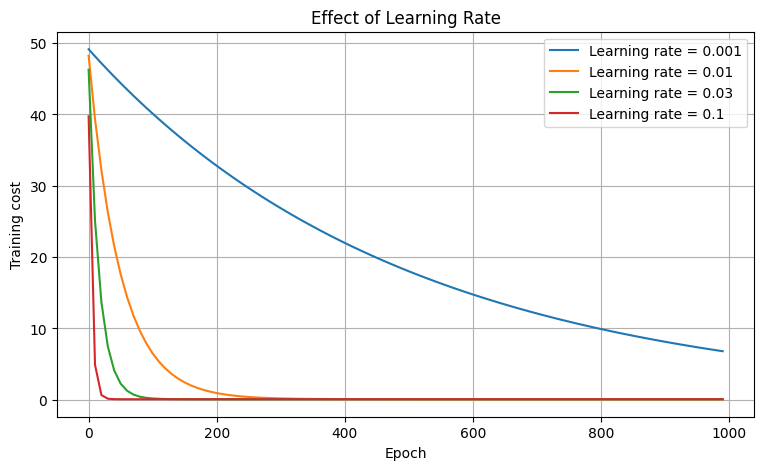

In [44]:
learning_rates = [0.001, 0.01, 0.03, 0.1]

plt.figure(figsize=(9, 5))

for lr in learning_rates:
    _, _, history = batch_gradient_descent(
        X_train_scaled,
        y_train_log,
        learning_rate=lr,
        epochs=1000
    )

    plt.plot(
        np.arange(len(history)) * 10,
        history,
        label=f"Learning rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training cost")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(True)
plt.show()


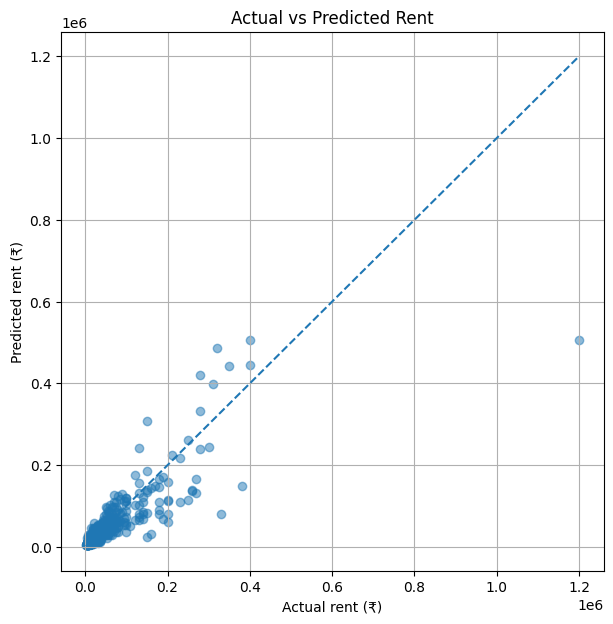

In [45]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test, y_pred,
    alpha=0.5
)

lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--"
)

plt.xlabel("Actual rent (₹)")
plt.ylabel("Predicted rent (₹)")
plt.title("Actual vs Predicted Rent")
plt.grid(True)
plt.show()

# Analyze residuals

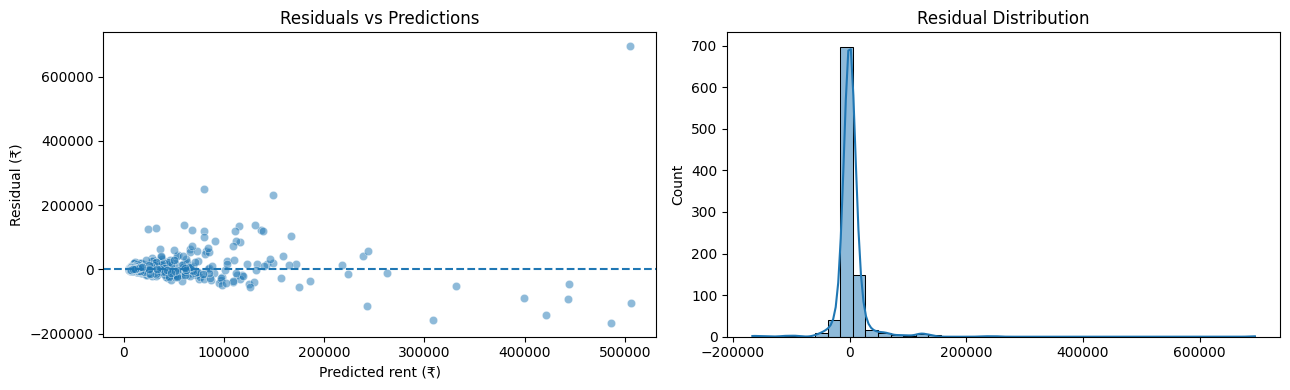

In [47]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5,
    ax=axes[0]
)

axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Predicted rent (₹)")
axes[0].set_ylabel("Residual (₹)")
axes[0].set_title("Residuals vs Predictions")

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

In [48]:
# model weight 

weights_df = pd.DataFrame({
    "Feature": X.columns if False else [
        "Feature " + str(i)
        for i in range(len(w_batch))
    ],
    "Weight": w_batch
})

display(
    weights_df.assign(
        Absolute_Weight=weights_df["Weight"].abs()
    ).sort_values(
        "Absolute_Weight", ascending=False
    ).head(20)
)

,Feature,Weight,Absolute_Weight
10,Feature 10,0.284682,0.284682
1,Feature 1,0.231878,0.231878
0,Feature 0,0.180678,0.180678
2,Feature 2,0.162272,0.162272
9,Feature 9,-0.124661,0.124661
8,Feature 8,-0.113699,0.113699
20,Feature 20,0.081035,0.081035
22,Feature 22,-0.080871,0.080871
11,Feature 11,0.065278,0.065278
4,Feature 4,0.060409,0.060409
